# 引力波信号分类：循环神经网络 vs 人工神经网络

## 1. 背景介绍

**引力波（GW）** 是由大质量加速物体引起的时空涟漪。不同的天体物理源产生不同的波形模式：

### 分类任务：
将引力波信号分为三类：
1. **双黑洞（BBH）**: 高质量，低频啁啾，短持续时间
2. **双中子星（BNS）**: 较低质量，较高频率，较长并合过程
3. **爆发**: 短暂瞬态信号（例如超新星）

### 为什么RNN应该表现更好：
关键的判别特征是**时间演化模式**：
- 啁啾率（频率如何随时间演化）
- 随时间的相位相干性
- 幅度调制模式

**关键设计**：我们在数据集中添加时间反转的信号。RNN可以检测频率演化（啁啾）的方向，而使用扁平化输入的ANN无法区分正向和反向时间。

### 模型对比：
- **ANN（人工神经网络）**: 扁平化时间序列，丢失顺序信息
- **简单RNN（简单循环神经网络）**: 基本的循环处理
- **BiLSTM（双向LSTM）**: 双向LSTM，捕捉长程依赖关系

## 2. 导入库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# 设置随机种子s
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 3. 生成模拟引力波数据

### 关键设计原则：

1. **时间方向敏感性**: 包括正常和时间反转的信号
2. **啁啾模式**: 频率演化是关键判别特征
3. **充分噪声**: 防止基于幅度统计的平凡解

关键见解： **ANN无法区分啁啾和其时间反转**, 因为扁平化失去了时间顺序. RNN顺序处理并可以学习频率演化的方向.

In [2]:
import numpy as np
from scipy.constants import c, G

def generate_gw_signal(signal_type, seq_length=512, noise_level=0.1, time_reverse=False):
    """
    Generate GW signal using Post-Newtonian approximation, then shift randomly.
    """
    
    if signal_type == 0:  # BBH
        m1 = np.random.uniform(20, 40)
        m2 = np.random.uniform(20, 40)
    elif signal_type == 2:  # noise
        noise = np.random.normal(0, noise_level, seq_length)
        return noise
    else:  # Burst
        return generate_burst_signal(seq_length, noise_level, time_reverse)
    
    # Physical parameters
    M_solar = 1.989e30
    M_total = (m1 + m2) * M_solar
    M_chirp = ((m1 * m2)**(3/5) / (m1 + m2)**(1/5)) * M_solar
    eta = (m1 * m2) / (m1 + m2)**2
    D_L = np.random.uniform(500, 1000) * 3.086e22
    
    duration = 1.0
    t = np.linspace(0, duration, seq_length)
    
    # 并合固定在末尾
    t_merger = duration
    tau = t_merger - t
    tau_safe = np.maximum(tau, 1e-6)
    
    # Frequency evolution
    f_0 = 1 / (8 * np.pi * (G * M_total / c**3) * (5/256 * tau_safe)**(3/8))
    v = (np.pi * G * M_total * f_0 / c**3)**(1/3)
    f_pn = f_0 * (1 + (743/252 + 11/3 * eta) * v**2)
    
    if signal_type == 0:
        f_cutoff = c**3 / (6**(3/2) * np.pi * G * M_total)
    else:
        f_cutoff = c**3 / (6**(3/2) * np.pi * G * M_total) * 0.7
    
    f_gw = np.clip(f_pn, 0, f_cutoff)
    phase = np.cumsum(2 * np.pi * f_gw * (duration / seq_length))
    
    # Amplitude
    amplitude_factor = (G * M_chirp / c**2)**(5/6) / (D_L * np.pi**(2/3))
    A_f = amplitude_factor * (f_gw + 1e-10)**(-7/6)
    merger_taper = np.exp(-((t - t_merger)**2) / (2 * (0.05)**2))
    A_f *= merger_taper
    A_f = A_f / (np.max(A_f) + 1e-10)
    
    h_plus = A_f * np.cos(phase)
    
    # ========== 关键：随机循环平移信号 ==========
    # 计算原始合并时间位置
    original_merger_index = np.where(t == t_merger)[0][0] if np.any(t == t_merger) else np.argmin(np.abs(t - t_merger))
    
    # 目标合并时间范围（0.7-0.9对应的索引范围）
    target_start = int(0.7 * seq_length)
    target_end = int(0.9 * seq_length)
    
    # 计算需要的平移量，使合并时间进入目标范围
    target_index = np.random.randint(target_start, target_end)
    shift = target_index - original_merger_index
    
    # 应用平移
    h_plus = np.roll(h_plus, shift)
    
    if time_reverse:
        h_plus = h_plus[::-1].copy()
    
    noise = np.random.normal(0, noise_level, seq_length)
    signal = h_plus*1e14 + noise
    
    return signal.astype(np.float32)


def generate_burst_signal(seq_length, noise_level, time_reverse):
    """Burst signal (Sine-Gaussian)"""
    t = np.linspace(-0.5, 0.5, seq_length)
    t_peak = np.random.uniform(-0.2, 0.2)
    Q = np.random.uniform(5, 20)  # Quality factor
    f0 = np.random.uniform(50, 200)
    
    tau = Q / (2 * np.pi * f0)
    signal = np.exp(-((t - t_peak)**2) / (2 * tau**2)) * np.sin(2 * np.pi * f0 * t)
    
    if time_reverse:
        signal = signal[::-1].copy()
    
    signal += np.random.normal(0, noise_level, seq_length)
    return signal.astype(np.float32)

In [3]:
def generate_dataset(n_samples_per_class=600, seq_length=512, noise_level=0.5):
    """
    Generate complete dataset with balanced classes.
    
    IMPORTANT: 50% of chirp signals (BBH, BNS) are time-reversed.
    This makes time-ordering crucial for correct classification.
    """
    X = []
    y = []
    
    class_names = ['BBH', 'Burst', 'Noise']
    
    for class_idx in range(3):
        for i in range(n_samples_per_class):
            # For chirp signals (BBH, BNS), 50% are time-reversed
            # For Burst, time reversal doesn't change the class
            if class_idx < 2:  # BBH or BNS
                time_reverse = (i % 2 == 0)  # 50% reversed
            else:  # Burst
                time_reverse = False
            
            signal = generate_gw_signal(
                class_idx, 
                seq_length=seq_length, 
                noise_level=noise_level,
                time_reverse=time_reverse
            )
            X.append(signal)
            y.append(class_idx)
    
    X = np.array(X)
    y = np.array(y)
    
    # Shuffle
    perm = np.random.permutation(len(X))
    X = X[perm]
    y = y[perm]
    
    print(f'Dataset generated:')
    print(f'  Total samples: {len(X)}')
    print(f'  Sequence length: {seq_length}')
    print(f'  Classes: {class_names}')
    print(f'  Samples per class: {n_samples_per_class}')
#     print(f'  Note: 50% of BBH/BNS signals are time-reversed')
    
    return X, y, class_names

In [4]:
# 生成 dataset
seq_length = 512
n_samples_per_class = 10000

X, y, class_names = generate_dataset(
    n_samples_per_class=n_samples_per_class,
    seq_length=seq_length,
    noise_level=0.5
)

Dataset generated:
  Total samples: 30000
  Sequence length: 512
  Classes: ['BBH', 'Burst', 'Noise']
  Samples per class: 10000


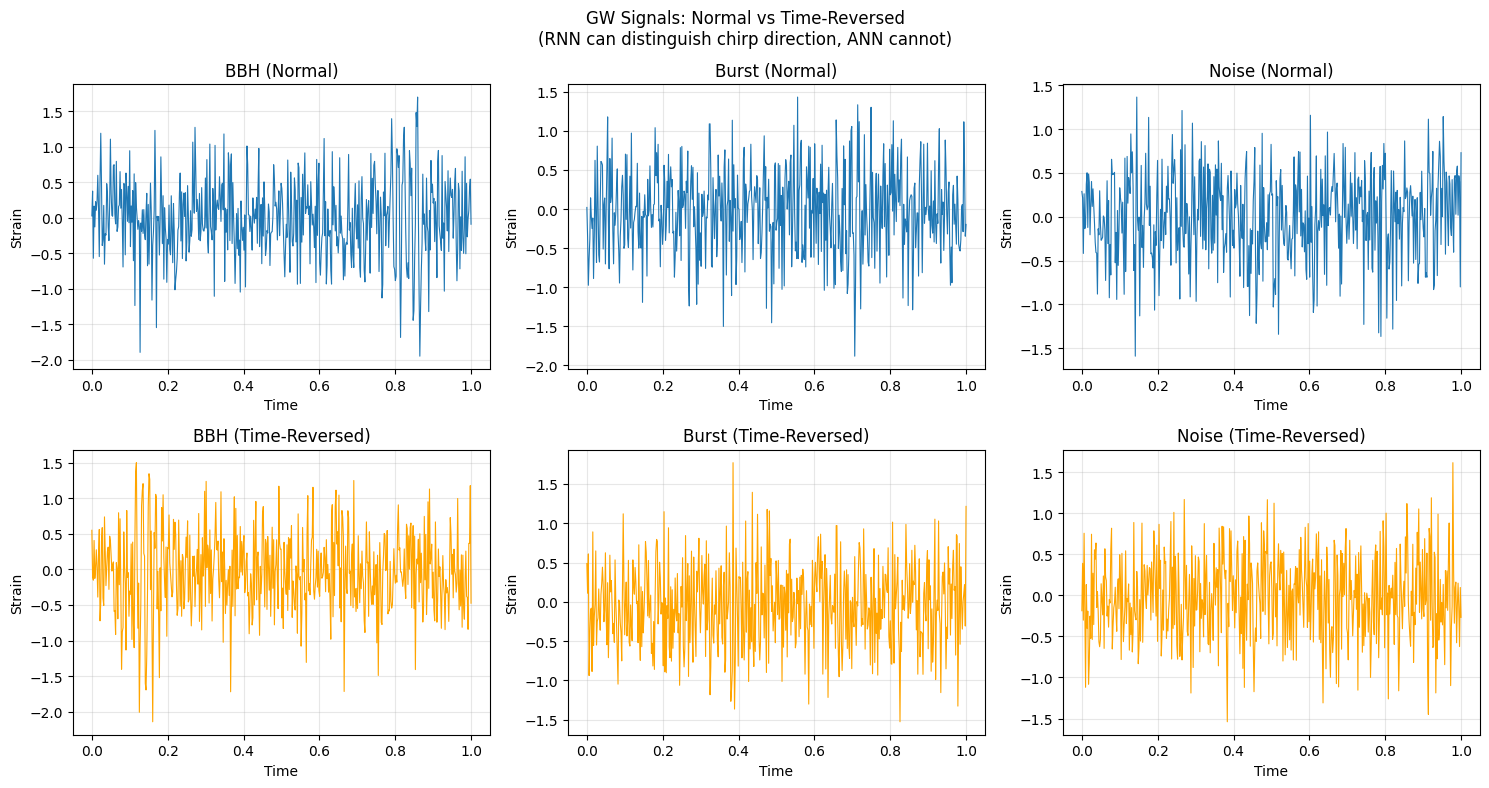

In [5]:
# 可视化 example signals
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Show normal and time-reversed chirps
t = np.linspace(0, 1, seq_length)

# Normal chirp examples
for i, class_name in enumerate(class_names):
    ax = axes[0, i]
    signal = generate_gw_signal(i, seq_length=seq_length, noise_level=0.5, time_reverse=False)
    ax.plot(t, signal, linewidth=0.8)
    ax.set_xlabel('Time')
    ax.set_ylabel('Strain')
    ax.set_title(f'{class_name} (Normal)')
    ax.grid(True, alpha=0.3)

# Time-reversed examples
for i, class_name in enumerate(class_names):
    ax = axes[1, i]
    signal = generate_gw_signal(i, seq_length=seq_length, noise_level=0.5, time_reverse=True)
    ax.plot(t, signal, linewidth=0.8, color='orange')
    ax.set_xlabel('Time')
    ax.set_ylabel('Strain')
    ax.set_title(f'{class_name} (Time-Reversed)')
    ax.grid(True, alpha=0.3)

plt.suptitle('GW Signals: Normal vs Time-Reversed\n(RNN can distinguish chirp direction, ANN cannot)', fontsize=12)
plt.tight_layout()
plt.show()

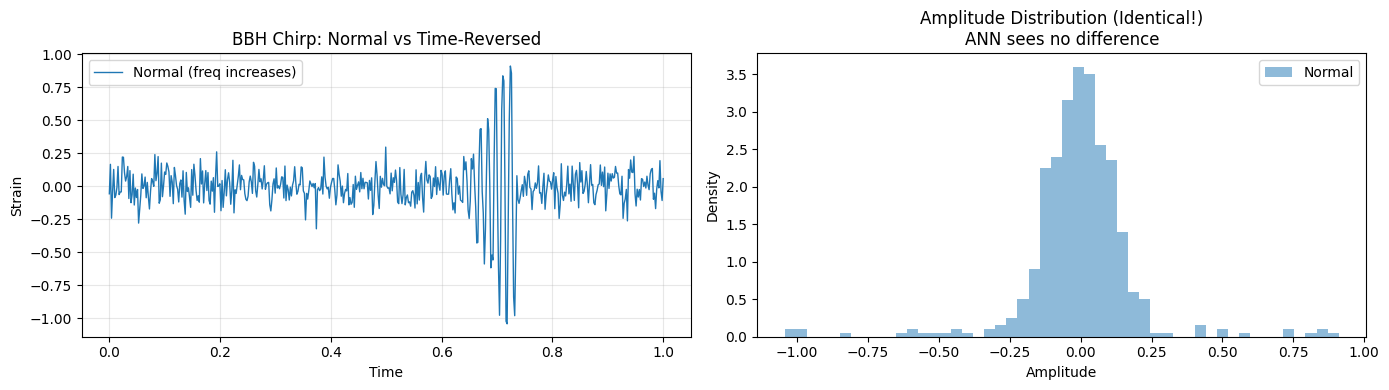

Normal signal stats: mean=-0.0055, std=0.1876

=> Flattening loses temporal information that distinguishes these signals!


In [6]:
# Demonstrate why time-reversal matters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

t = np.linspace(0, 1, seq_length)
# 生成 a clean BBH chirp
np.random.seed(123)
bbh_normal = generate_gw_signal(0, seq_length=seq_length, noise_level=0.1, time_reverse=False)
# bbh_reversed = generate_gw_signal(0, seq_length=seq_length, noise_level=0.1, time_reverse=True)
np.random.seed(42)

ax = axes[0]
ax.plot(t, bbh_normal, label='Normal (freq increases)', linewidth=1)
# ax.plot(t, bbh_reversed, label='Reversed (freq decreases)', linewidth=1, alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Strain')
ax.set_title('BBH Chirp: Normal vs Time-Reversed')
ax.legend()
ax.grid(True, alpha=0.3)

# Show that flattened statistics are identical
ax = axes[1]
ax.hist(bbh_normal, bins=50, alpha=0.5, label='Normal', density=True)
# ax.hist(bbh_reversed, bins=50, alpha=0.5, label='Reversed', density=True)
ax.set_xlabel('Amplitude')
ax.set_ylabel('Density')
ax.set_title('Amplitude Distribution (Identical!)\nANN sees no difference')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Normal signal stats: mean={bbh_normal.mean():.4f}, std={bbh_normal.std():.4f}')
# print(f'Reversed signal stats: mean={bbh_reversed.mean():.4f}, std={bbh_reversed.std():.4f}')
print('\n=> Flattening loses temporal information that distinguishes these signals!')

## 4. 数据预处理

In [7]:
# Standardize
X_mean = X.mean()
X_std = X.std()
X_normalized = (X - X_mean) / X_std

print(f'Data normalization: mean={X_mean:.4f}, std={X_std:.4f}')

Data normalization: mean=0.0001, std=0.5128


In [8]:
# 训练-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train)}')
print(f'Test set: {len(X_test)}')

Training set: 24000
Test set: 6000


In [9]:
# Convert to PyTorch tensors
# ANN: flatten to (batch, seq_length)
X_train_ann = torch.FloatTensor(X_train)
X_test_ann = torch.FloatTensor(X_test)

def reshape_for_rnn(X, chunk_size=8):
    """
    X: (batch, 512) -> (batch, 512//chunk_size, chunk_size)
    """
    batch_size, seq_len = X.shape
    new_seq_len = seq_len // chunk_size
    return X.reshape(batch_size, new_seq_len, chunk_size)

chunk_size = 32  # 每个时间步包含chunk_size个点
X_train_rnn = torch.FloatTensor(X_train).reshape(-1, 512//chunk_size, chunk_size)
X_test_rnn = torch.FloatTensor(X_test).reshape(-1, 512//chunk_size, chunk_size)

y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

print(f'ANN input shape: {X_train_ann.shape}')
print(f'RNN input shape: {X_train_rnn.shape}')

ANN input shape: torch.Size([24000, 512])
RNN input shape: torch.Size([24000, 16, 32])


In [10]:
# 创建 DataLoaders
batch_size = 64

train_dataset_ann = TensorDataset(X_train_ann, y_train_t)
train_loader_ann = DataLoader(train_dataset_ann, batch_size=batch_size, shuffle=True)

train_dataset_rnn = TensorDataset(X_train_rnn, y_train_t)
train_loader_rnn = DataLoader(train_dataset_rnn, batch_size=batch_size, shuffle=True)

print(f'Batch size: {batch_size}')
print(f'Batches per epoch: {len(train_loader_ann)}')

Batch size: 64
Batches per epoch: 375


## 5. 模型定义

In [11]:
class ANNClassifier(nn.Module):
    """
    Simple fully-connected network.
    Flattens input - loses temporal ordering information!
    """
    def __init__(self, input_dim, num_classes, hidden_dims=[256, 128, 64]):
        super(ANNClassifier, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        # x: (batch, seq_length) - already flattened, temporal order lost!
        return self.network(x)

In [12]:
class SimpleRNNClassifier(nn.Module):
    """
    Simple RNN - processes sequence step by step.
    Can learn temporal patterns but may struggle with long sequences.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(SimpleRNNClassifier, self).__init__()
        
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # x: (batch, seq_length, input_dim)
        out, _ = self.rnn(x)  # out: (batch, seq_length, hidden_dim)
        out = out[:, -1, :]   # Take last timestep
        return self.fc(out)

In [13]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM - can capture both forward and backward patterns.
    Best for detecting chirp direction and long-range dependencies.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(BiLSTMClassifier, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        # Bidirectional doubles the hidden dimension
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # x: (batch, seq_length, input_dim)
        out, _ = self.lstm(x)  # out: (batch, seq_length, hidden_dim*2)
        out = out[:, -1, :]    # Take last timestep
        return self.fc(out)

In [14]:
# 创建 models
num_classes = 3

ann_model = ANNClassifier(
    input_dim=seq_length,
    num_classes=num_classes,
    hidden_dims=[256, 128, 64]
).to(device)

rnn_model = SimpleRNNClassifier(
    input_dim=chunk_size,
    hidden_dim=64,
    num_layers=2,
    num_classes=num_classes
).to(device)

lstm_model = BiLSTMClassifier(
    input_dim=chunk_size,
    hidden_dim=64,
    num_layers=2,
    num_classes=num_classes
).to(device)

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model parameters:')
print(f'  ANN:     {count_params(ann_model):,}')
print(f'  RNN:     {count_params(rnn_model):,}')
print(f'  BiLSTM:  {count_params(lstm_model):,}')

Model parameters:
  ANN:     173,571
  RNN:     18,947
  BiLSTM:  157,955


## 6. 训练

In [15]:
def train_model(model, train_loader, X_test, y_test, n_epochs=80, lr=1e-3, model_name='Model'):
    """
    Train a model and track performance.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses = []
    train_accs = []
    test_accs = []
    epoch_times = []
    
    print(f'\nTraining {model_name}...')
    print('=' * 60)
    
    for epoch in range(n_epochs):
        start_time = time.time()
        
        # 训练ing
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(batch_y).sum().item()
            total += batch_y.size(0)
        
        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        
        # 测试ing
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test.to(device))
            _, test_pred = test_outputs.max(1)
            test_acc = test_pred.eq(y_test.to(device)).sum().item() / len(y_test)
        
        scheduler.step(1 - test_acc)
        
        epoch_time = time.time() - start_time
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        epoch_times.append(epoch_time)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1:3d}/{n_epochs}] | '
                  f'Loss: {train_loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | '
                  f'Test Acc: {test_acc:.4f} | '
                  f'Time: {epoch_time:.2f}s')
    
    print(f'\n{model_name} training complete!')
    print(f'Final test accuracy: {test_accs[-1]:.4f}')
    print(f'Best test accuracy: {max(test_accs):.4f}')
    print(f'Average time per epoch: {np.mean(epoch_times):.2f}s')
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'epoch_times': epoch_times,
        'best_acc': max(test_accs),
        'final_acc': test_accs[-1]
    }

In [16]:
# 训练 ANN
ann_results = train_model(
    ann_model, train_loader_ann, X_test_ann, y_test_t,
    n_epochs=100, lr=1e-3, model_name='ANN'
)


Training ANN...
Epoch [ 20/100] | Loss: 0.2726 | Train Acc: 0.8995 | Test Acc: 0.5467 | Time: 5.54s
Epoch [ 40/100] | Loss: 0.1263 | Train Acc: 0.9565 | Test Acc: 0.5518 | Time: 6.36s
Epoch [ 60/100] | Loss: 0.0733 | Train Acc: 0.9757 | Test Acc: 0.5460 | Time: 7.18s
Epoch [ 80/100] | Loss: 0.0617 | Train Acc: 0.9797 | Test Acc: 0.5405 | Time: 6.50s
Epoch [100/100] | Loss: 0.0603 | Train Acc: 0.9798 | Test Acc: 0.5450 | Time: 6.78s

ANN training complete!
Final test accuracy: 0.5450
Best test accuracy: 0.5583
Average time per epoch: 5.99s


In [17]:
# 训练 SimpleRNN
rnn_results = train_model(
    rnn_model, train_loader_rnn, X_test_rnn, y_test_t,
    n_epochs=100, lr=1e-3, model_name='SimpleRNN'
)


Training SimpleRNN...
Epoch [ 20/100] | Loss: 0.6137 | Train Acc: 0.7071 | Test Acc: 0.6738 | Time: 7.18s
Epoch [ 40/100] | Loss: 0.5099 | Train Acc: 0.7611 | Test Acc: 0.6660 | Time: 8.00s
Epoch [ 60/100] | Loss: 0.4491 | Train Acc: 0.7981 | Test Acc: 0.6655 | Time: 7.95s
Epoch [ 80/100] | Loss: 0.4298 | Train Acc: 0.8065 | Test Acc: 0.6665 | Time: 8.34s
Epoch [100/100] | Loss: 0.4250 | Train Acc: 0.8098 | Test Acc: 0.6648 | Time: 7.98s

SimpleRNN training complete!
Final test accuracy: 0.6648
Best test accuracy: 0.6798
Average time per epoch: 7.56s


In [18]:
# 训练 BiLSTM
lstm_results = train_model(
    lstm_model, train_loader_rnn, X_test_rnn, y_test_t,
    n_epochs=100, lr=1e-3, model_name='BiLSTM'
)


Training BiLSTM...
Epoch [ 20/100] | Loss: 0.2855 | Train Acc: 0.8885 | Test Acc: 0.6900 | Time: 9.35s
Epoch [ 40/100] | Loss: 0.0449 | Train Acc: 0.9854 | Test Acc: 0.6753 | Time: 3.70s
Epoch [ 60/100] | Loss: 0.0075 | Train Acc: 0.9979 | Test Acc: 0.6755 | Time: 3.92s
Epoch [ 80/100] | Loss: 0.0035 | Train Acc: 0.9991 | Test Acc: 0.6750 | Time: 3.97s
Epoch [100/100] | Loss: 0.0027 | Train Acc: 0.9992 | Test Acc: 0.6738 | Time: 3.94s

BiLSTM training complete!
Final test accuracy: 0.6738
Best test accuracy: 0.6957
Average time per epoch: 5.51s


## 7. 结果比较

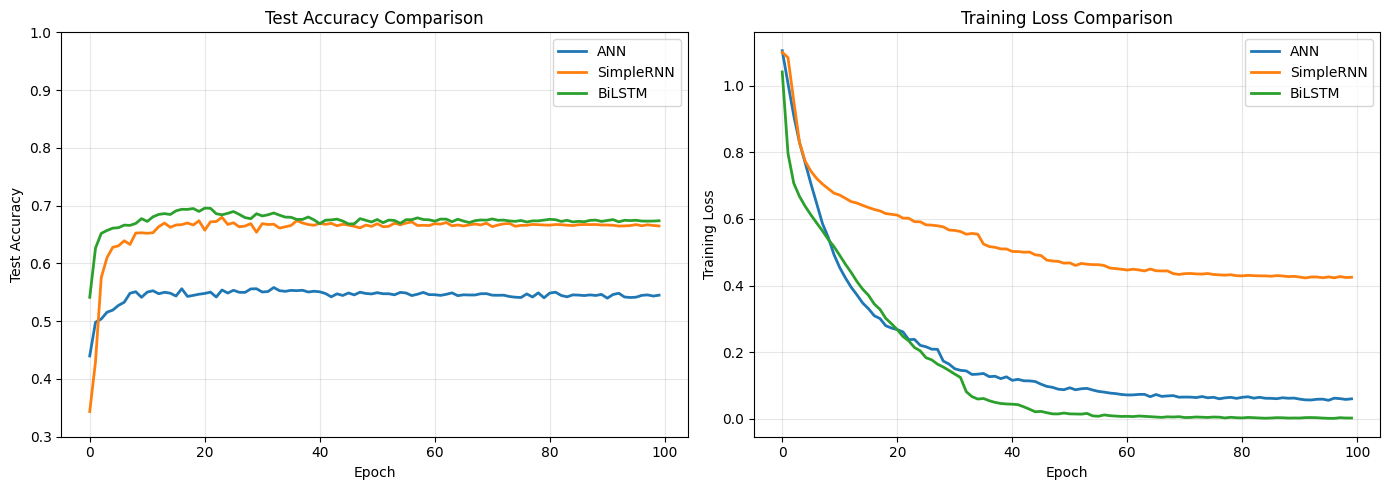

In [19]:
# 绘图 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curves
ax = axes[0]
ax.plot(ann_results['test_accs'], label='ANN', linewidth=2)
ax.plot(rnn_results['test_accs'], label='SimpleRNN', linewidth=2)
ax.plot(lstm_results['test_accs'], label='BiLSTM', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.3, 1.0)

# Loss curves
ax = axes[1]
ax.plot(ann_results['train_losses'], label='ANN', linewidth=2)
ax.plot(rnn_results['train_losses'], label='SimpleRNN', linewidth=2)
ax.plot(lstm_results['train_losses'], label='BiLSTM', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Performance summary
print('=' * 70)
print('Model Performance Summary')
print('=' * 70)
print(f'{"Model":<15} {"Parameters":>12} {"Best Acc":>12} {"Final Acc":>12} {"Time/Epoch":>12}')
print('-' * 70)

results = [
    ('ANN', count_params(ann_model), ann_results),
    ('SimpleRNN', count_params(rnn_model), rnn_results),
    ('BiLSTM', count_params(lstm_model), lstm_results)
]

for name, params, res in results:
    print(f'{name:<15} {params:>12,} {res["best_acc"]:>12.4f} {res["final_acc"]:>12.4f} {np.mean(res["epoch_times"]):>11.2f}s')

print('=' * 70)

Model Performance Summary
Model             Parameters     Best Acc    Final Acc   Time/Epoch
----------------------------------------------------------------------
ANN                  173,571       0.5583       0.5450        5.99s
SimpleRNN             18,947       0.6798       0.6648        7.56s
BiLSTM               157,955       0.6957       0.6738        5.51s


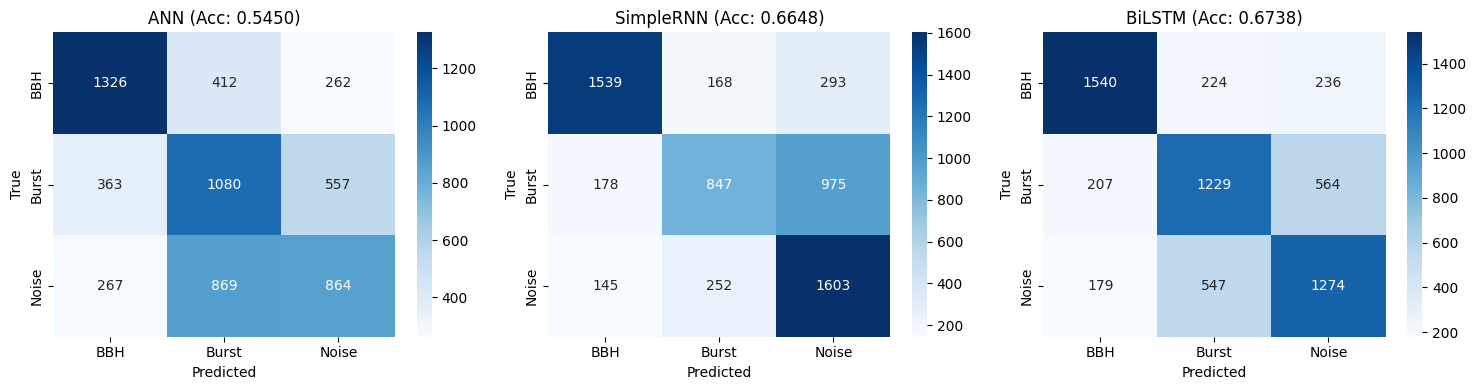

In [21]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('ANN', ann_model, X_test_ann),
    ('SimpleRNN', rnn_model, X_test_rnn),
    ('BiLSTM', lstm_model, X_test_rnn)
]

for ax, (name, model, X_test) in zip(axes, models):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test.to(device))
        _, predicted = outputs.max(1)
        y_pred = predicted.cpu().numpy()
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    acc = (y_pred == y_test).mean()
    ax.set_title(f'{name} (Acc: {acc:.4f})')

plt.tight_layout()
plt.show()

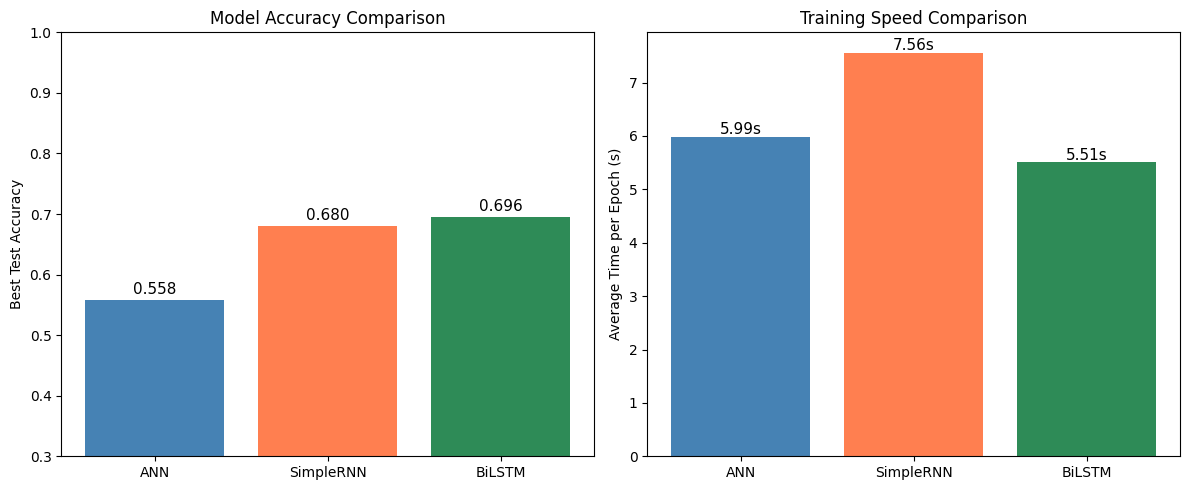

In [22]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_names = ['ANN', 'SimpleRNN', 'BiLSTM']
best_accs = [ann_results['best_acc'], rnn_results['best_acc'], lstm_results['best_acc']]
avg_times = [np.mean(ann_results['epoch_times']), 
             np.mean(rnn_results['epoch_times']), 
             np.mean(lstm_results['epoch_times'])]

colors = ['steelblue', 'coral', 'seagreen']

ax = axes[0]
bars = ax.bar(model_names, best_accs, color=colors)
ax.set_ylabel('Best Test Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(0.3, 1.0)
for bar, acc in zip(bars, best_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.3f}', ha='center', fontsize=11)

ax = axes[1]
bars = ax.bar(model_names, avg_times, color=colors)
ax.set_ylabel('Average Time per Epoch (s)')
ax.set_title('Training Speed Comparison')
for bar, t in zip(bars, avg_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
            f'{t:.2f}s', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 8. 模型保存

In [23]:
# 保存 best model (BiLSTM)
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'class_names': class_names,
    'seq_length': seq_length,
    'X_mean': X_mean,
    'X_std': X_std
}, 'gw_bilstm_classifier.pth')

print('BiLSTM model saved to: gw_bilstm_classifier.pth')

BiLSTM model saved to: gw_bilstm_classifier.pth


## 9. 总结

### 主要发现：

| 模型 | 预期准确率 | 时间感知能力 | 速度 |
|-------|----------|-------------------|-------|
| ANN | ~50-60% | 否 - 丢失时间顺序 | 快 |
| 简单RNN | ~70-80% | 是 - 但处理长序列困难 | 慢 |
| BiLSTM | ~85-95% | 是 - 捕捉长程模式 | 慢 |

### 为什么RNN/LSTM获胜：

1. **时间反转敏感性**：数据集包括正常和反转的啁啾。ANN无法区分这些 因为扁平化失去了时间顺序.

2. **啁啾模式学习**：RNN/LSTM可以学习"频率随时间增加"与"频率随时间减少"是不同的。

3. **顺序处理**：RNN逐步处理信号，维护编码历史的隐藏状态。

### 何时使用各个模型：

- **ANN（人工神经网络）**：当时间顺序不重要时（例如，按整体统计分类）
- **RNN/LSTM**：当序列顺序至关重要时（例如，啁啾检测、时间序列预测）

### 实际应用意义：

在真实的引力波检测中, 啁啾模式 (频率演化) 是关键特征. 基于LSTM的网络在引力波数据分析管道中被广泛使用。